In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Eco_.xlsx to Eco_ (1).xlsx


In [ ]:
import pandas as pd

# Load Excel file
excel_file = "Eco_.xlsx"

# See all sheets in the file
xls = pd.ExcelFile(excel_file)

print(xls.sheet_names)


['Orders Table', 'Sheet1', 'Customers Table', 'Sheet2', 'Products Table', 'Sheet3']


In [ ]:
import os

print(os.listdir())


['.config', 'Eco_.xlsx', 'Eco_ (1).xlsx', 'sample_data']


In [ ]:
import pandas as pd
import os

# ==========================================
# 1. Load the file
# ==========================================

eco_file = "Eco_.xlsx"

orders = pd.read_excel(
    eco_file,
    sheet_name="Orders Table"
)

customers = pd.read_excel(
    eco_file,
    sheet_name="Customers Table"
)

products = pd.read_excel(
    eco_file,
    sheet_name="Products Table"
)


# ==========================================
# 2. Convert dates
# ==========================================

orders['Order_Date'] = pd.to_datetime(
    orders['Order_Date'],
    format='%d-%m-%Y %H:%M:%S'
)

customers['Signup_Date'] = pd.to_datetime(
    customers['Signup_Date']
)


# ==========================================
# 3. Create Revenue
# ==========================================

orders['Revenue'] = (
    orders['Quantity']
    * orders['Price']
    * (1 - orders['Discount'])
)


# ==========================================
# 4. Create RFM Features
# ==========================================

reference_date = orders['Order_Date'].max()

rfm = orders.groupby('Customer_ID').agg(
    Recency=(
        'Order_Date',
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        'Order_ID',
        'count'
    ),
    Monetary=(
        'Revenue',
        'sum'
    )
).reset_index()


# ==========================================
# 5. Merge RFM with Customer Information
# ==========================================

customer_rfm = customers.merge(
    rfm,
    on='Customer_ID',
    how='left'
)


# ==========================================
# 6. Display Results
# ==========================================

print("Revenue:")
display(orders[['Order_ID', 'Customer_ID', 'Quantity',
                'Price', 'Discount', 'Revenue']].head())

print("RFM Features:")
display(rfm.head())

print("Customer RFM:")
display(customer_rfm.head())


Revenue:


,Order_ID,Customer_ID,Quantity,Price,Discount,Revenue
0,1001,C001,2,500,0.10,900.0
1,1002,C002,1,1200,0.05,1140.0
2,1003,C003,3,750,0.15,1912.5
3,1004,C004,2,300,0.00,600.0
4,1005,C005,5,450,0.10,2025.0


RFM Features:


,Customer_ID,Recency,Frequency,Monetary
0,C001,14,5,13255.0
1,C002,13,5,6840.0
2,C003,12,5,11997.5
3,C004,11,5,10800.0
4,C005,10,5,8995.0


Customer RFM:


,Customer_ID,Name,Age,Gender,City,Signup_Date,Recency,Frequency,Monetary
0,C001,Aarav Sharma,24,Male,Delhi,2024-01-05,14.0,5.0,13255.0
1,C002,Ananya Verma,27,Female,Mumbai,2024-01-08,13.0,5.0,6840.0
2,C003,Rohan Gupta,31,Male,Jaipur,2024-01-12,12.0,5.0,11997.5
3,C004,Priya Singh,22,Female,Lucknow,2024-01-15,11.0,5.0,10800.0
4,C005,Arjun Mehta,29,Male,Pune,2024-01-18,10.0,5.0,8995.0


In [ ]:
# ==========================================
# CUSTOMER SEGMENTATION
# ==========================================

# Create segments based on Monetary value
customer_rfm['Value_Segment'] = pd.qcut(
    customer_rfm['Monetary'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

# Check number of customers in each segment
print(customer_rfm['Value_Segment'].value_counts())

# View customers
display(
    customer_rfm[
        ['Customer_ID', 'Name', 'Recency',
         'Frequency', 'Monetary', 'Value_Segment']
    ].sort_values('Monetary', ascending=False)
)


Value_Segment
Low Value       7
High Value      7
Medium Value    6
Name: count, dtype: int64


,Customer_ID,Name,Recency,Frequency,Monetary,Value_Segment
9,C010,Pooja Mishra,5.0,5.0,15975.0,High Value
0,C001,Aarav Sharma,14.0,5.0,13255.0,High Value
14,C015,Manish Kumar,0.0,5.0,12162.5,High Value
2,C003,Rohan Gupta,12.0,5.0,11997.5,High Value
12,C013,Vikram Yadav,2.0,5.0,11257.5,High Value
...,...,...,...,...,...,...
100,C101,Devendra Singh,NaN,NaN,NaN,NaN
101,C102,Shweta Joshi,NaN,NaN,NaN,NaN
102,C103,Rohit Bansal,NaN,NaN,NaN,NaN
103,C104,Aisha Khan,NaN,NaN,NaN,NaN


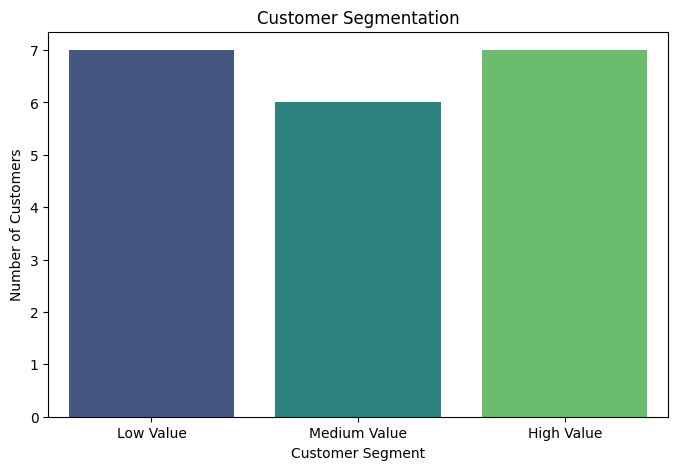

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_rfm,
    x='Value_Segment',
    hue='Value_Segment',
    palette='viridis',
    legend=False
)

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
segment_summary = customer_rfm.groupby(
    'Value_Segment',
    observed=True
).agg(
    Customers=('Customer_ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

display(segment_summary)


,Value_Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,Low Value,7,10.857143,4.571429,7359.285714
1,Medium Value,6,11.166667,4.666667,10543.333333
2,High Value,7,6.714286,5.000000,12415.714286


In [ ]:
# ==========================================
# COHORT ANALYSIS
# ==========================================

orders['Order_Month'] = (
    orders['Order_Date']
    .dt.to_period('M')
)


In [ ]:
customer_first_purchase = (
    orders.groupby('Customer_ID')['Order_Month']
    .min()
    .reset_index()
)

customer_first_purchase.columns = [
    'Customer_ID',
    'Cohort_Month'
]

display(customer_first_purchase.head())


,Customer_ID,Cohort_Month
0,C001,2025-01
1,C002,2025-01
2,C003,2025-01
3,C004,2025-01
4,C005,2025-01


In [ ]:
orders = orders.merge(
    customer_first_purchase,
    on='Customer_ID',
    how='left'
)



In [ ]:
orders['Cohort_Index'] = (
    (orders['Order_Month'].dt.year -
     orders['Cohort_Month'].dt.year) * 12
    +
    (orders['Order_Month'].dt.month -
     orders['Cohort_Month'].dt.month)
)


In [ ]:
cohort_data = (
    orders.groupby(
        ['Cohort_Month', 'Cohort_Index']
    )['Customer_ID']
    .nunique()
    .reset_index()
)

cohort_data.columns = [
    'Cohort_Month',
    'Cohort_Index',
    'Customers'
]


In [ ]:
cohort_table = cohort_data.pivot_table(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='Customers'
)

display(cohort_table)


Cohort_Index,0,1,2,3
Cohort_Month,,,,
2025-01,20.0,20.0,20.0,6.0


In [ ]:
cohort_size = cohort_table.iloc[:, 0]

retention_table = cohort_table.divide(
    cohort_size,
    axis=0
) * 100

display(retention_table.round(2))


Cohort_Index,0,1,2,3
Cohort_Month,,,,
2025-01,100.0,100.0,100.0,30.0


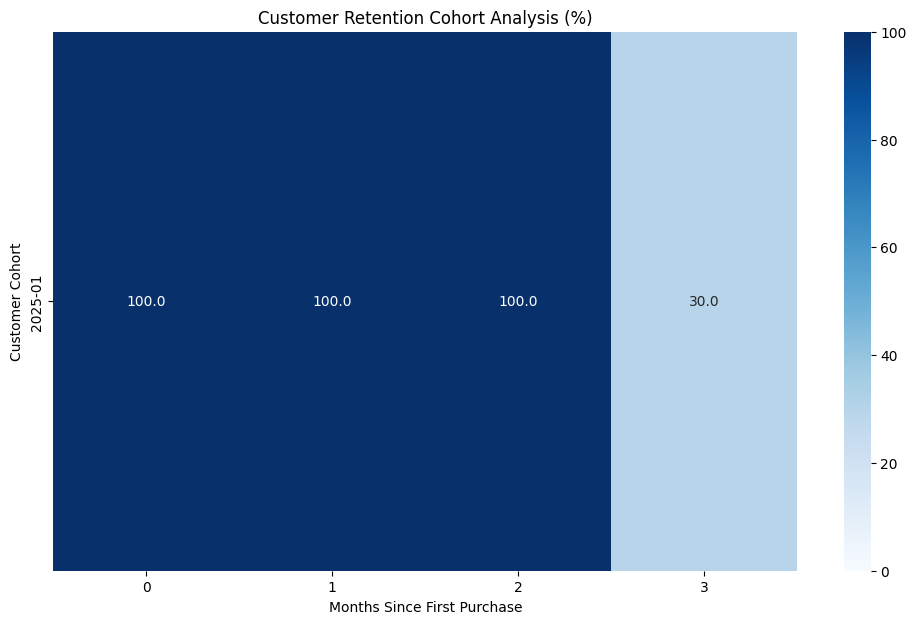

In [ ]:
plt.figure(figsize=(12,7))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100
)

plt.title('Customer Retention Cohort Analysis (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer Cohort')

plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Select RFM features
rfm_features = rfm[
    ['Recency', 'Frequency', 'Monetary']
].copy()

# Check for missing values
print(rfm_features.isnull().sum())


Recency      0
Frequency    0
Monetary     0
dtype: int64


In [ ]:
rfm_features = rfm_features.dropna()


In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

display(rfm.head())


,Customer_ID,Recency,Frequency,Monetary,Cluster
0,C001,14,5,13255.0,2
1,C002,13,5,6840.0,0
2,C003,12,5,11997.5,2
3,C004,11,5,10800.0,2
4,C005,10,5,8995.0,0


In [ ]:
cluster_summary = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Customers=('Customer_ID', 'count')
).reset_index()

display(cluster_summary)


,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Customers
0,0,7.0,5.0,7565.00,5
1,1,17.0,4.0,8888.50,5
2,2,7.0,5.0,11941.75,10


In [ ]:
cluster_labels = {
    0: 'VIP Customers',
    1: 'At Risk Customers',
    2: 'Regular Customers'
}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_labels)

display(rfm.head())


,Customer_ID,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,C001,14,5,13255.0,2,Regular Customers
1,C002,13,5,6840.0,0,VIP Customers
2,C003,12,5,11997.5,2,Regular Customers
3,C004,11,5,10800.0,2,Regular Customers
4,C005,10,5,8995.0,0,VIP Customers


In [ ]:
# Make sure Order_Date is datetime
orders['Order_Date'] = pd.to_datetime(
    orders['Order_Date']
)

# Monthly revenue
monthly_sales = (
    orders
    .set_index('Order_Date')
    .resample('ME')['Revenue']
    .sum()
)

display(monthly_sales)


,Revenue
Order_Date,
2025-01-31,59677.5
2025-02-28,57887.5
2025-03-31,69760.0
2025-04-30,14360.0


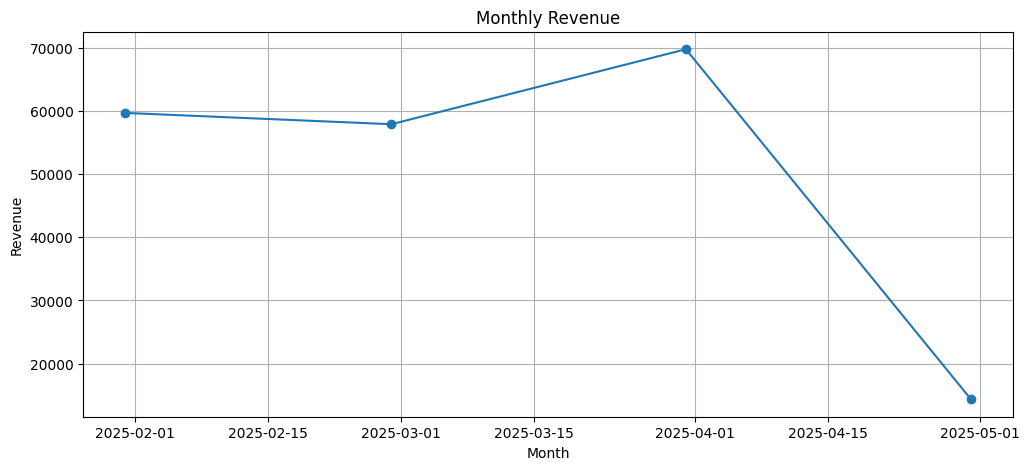

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_sales,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                    4
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -34.789
Date:                Sun, 13 Sep 2026   AIC                             75.577
Time:                        09:55:09   BIC                             72.873
Sample:                    01-31-2025   HQIC                            70.141
                         - 04-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9985      0.199     -5.021      0.000      -1.388      -0.609
ma.L1          0.9646      2.439      0.395      0.692      -3.816       5.745
sigma2      6.322e+08    3.9e-09   1.62e+17      0.0

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:989: EstimationWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  params_variance) = self._conditional_sum_squares(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3652: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  _het_result = breakvar_heteroskedasticity_test(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3652: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  _het_result = breakvar_heteroskedasticity_test(


In [ ]:
forecast = model_fit.forecast(steps=6)

print("Forecast:")
print(forecast)


Forecast:
2025-05-31    34863.785727
2025-06-30    14390.025108
2025-07-31    34833.804587
2025-08-31    14419.962344
2025-09-30    34803.911190
2025-10-31    14449.811966
Freq: ME, Name: predicted_mean, dtype: float64


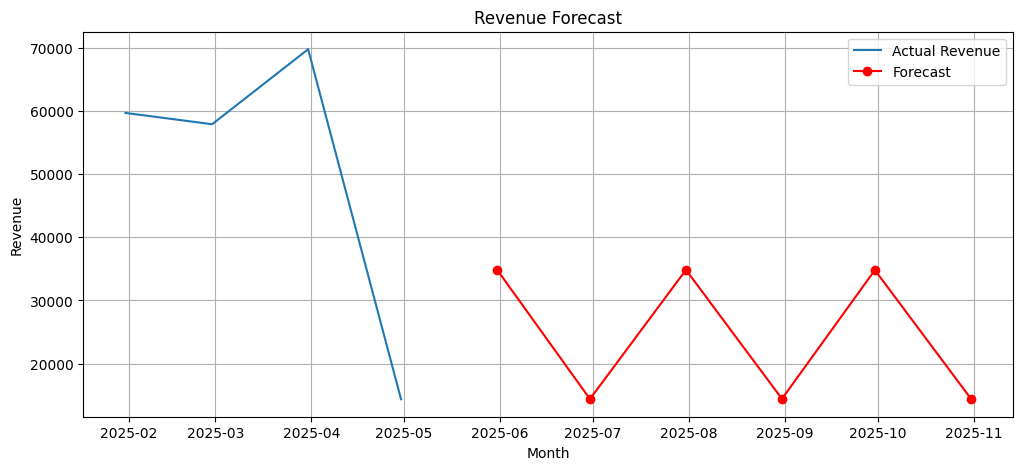

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales,
    label='Actual Revenue'
)

plt.plot(
    forecast.index,
    forecast,
    color='red',
    marker='o',
    label='Forecast'
)

plt.title('Revenue Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.legend()
plt.grid(True)

plt.show()


In [ ]:
!pip install mlxtend


In [ ]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
basket = (
    orders
    .groupby(['Customer_ID', 'Product_ID'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
basket_binary = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

display(basket_binary.head())


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Product_ID,P101,P102,P103,P104,P105,P106,P107,P108,P109,P110
Customer_ID,,,,,,,,,,
C001,1,0,1,0,1,0,0,0,1,1
C002,1,0,1,1,1,0,0,0,0,0
C003,1,1,0,0,0,0,0,1,0,1
C004,1,0,0,0,1,0,1,1,0,0
C005,0,0,1,1,1,0,1,0,0,1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
frequent_itemsets = apriori(
    basket_binary,
    min_support=0.05,
    use_colnames=True
)

display(frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(20))


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,support,itemsets
3,0.45,(P104)
4,0.45,(P105)
6,0.45,(P107)
8,0.45,(P109)
9,0.45,(P110)
2,0.40,(P103)
7,0.40,(P108)
1,0.30,(P102)
29,0.30,"(P110, P103)"
24,0.30,"(P104, P103)"


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
min_support=0.02


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

display(
    rules[
        ['antecedents',
         'consequents',
         'support',
         'confidence',
         'lift']
    ].sort_values(
        'lift',
        ascending=False
    ).head(20)
)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
633,"(P107, P109, P108)","(P102, P104)",0.05,0.500000,10.000000
664,"(P107, P110, P108)","(P105, P102)",0.05,0.500000,10.000000
681,"(P105, P102)","(P107, P110, P108)",0.05,1.000000,10.000000
652,"(P102, P104)","(P107, P109, P108)",0.05,1.000000,10.000000
607,"(P101, P110, P105)","(P109, P103)",0.05,1.000000,6.666667
750,"(P107, P110, P104)","(P108, P103)",0.05,0.333333,6.666667
392,"(P108, P110)","(P105, P102)",0.05,0.333333,6.666667
759,"(P108, P103)","(P107, P110, P104)",0.05,1.000000,6.666667
303,"(P108, P105)","(P101, P107)",0.05,0.333333,6.666667
302,"(P101, P107)","(P108, P105)",0.05,1.000000,6.666667


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
display(products.head())


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,at,Category,Sub_Category,Cost,Selling_Price
0,P001,Electronics,Smartphone,12000,14999
1,P002,Electronics,Laptop,35000,42999
2,P003,Electronics,Headphones,1200,1799
3,P004,Electronics,Smartwatch,2500,3499
4,P005,Electronics,Tablet,18000,21999


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag